# R04 — [Rebuttal] Template-Confound & Content-Matched Controls

**Reviewer concern addressed:** *"Each task uses a fixed instruction template. The 'task-identity
clusters' may simply be clusters of the literal template string, and the 'task-dependent
over-refusal geometry' may reduce to surface-form similarity rather than task identity."*

This is the sharpest possible objection to the paper's framing, and R01's design lets us
answer it directly with three controls:

| # | Control | Uses | Logic |
|---|---|---|---|
| 1 | **Template-paraphrase invariance** | 3 paraphrased templates per new task | If clusters were template-string clusters, each paraphrase would form its own sub-cluster |
| 2 | **Content-matched cross-task distance** | Same content strings across tasks | If content drove the geometry, same-content pairs would sit close *across* task frames |
| 3 | **Content-blocked task probe** | GroupKFold by `content_id` | Task must be decodable from representations of *unseen* contents |

**Inputs:** original bank + R01 bank. **Compute:** CPU only.
Headline numbers print with `[R4.x]` tags.


In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, re

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif', 'axes.titleweight': 'bold',
    'figure.facecolor': 'white', 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
rng = np.random.default_rng(42)
FIG_DIR = './figures'; os.makedirs(FIG_DIR, exist_ok=True)

## If on Colab, copy artefacts first (mirrors R02/R05):
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p embeddings rebuttal_embeddings
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/rebuttal/." ./rebuttal_embeddings/.

def load_bank(emb_dir):
    csvs = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    if len(csvs) > 1:
        print(f'  [load_bank {emb_dir}] WARNING: {len(csvs)} CSVs found: {csvs}')
        print(f'  [load_bank {emb_dir}] picking (sorted-last): {csvs[-1]} -- verify this is intended!')
    csv_df = pd.read_csv(os.path.join(emb_dir, csvs[-1]))
    REQUIRED_COLS = ['refusal_class', 'llm_evaluation', 'torch_path']
    missing = [c for c in REQUIRED_COLS if c not in csv_df.columns]
    if missing:
        raise ValueError(
            f"{emb_dir}: latest CSV ({csvs[-1]}) is missing columns {missing}. "
            "This usually means the CSV was persisted to Drive BEFORE the GPT-4o judging "
            "step ran in R01 (Step 3's save happens before Step 4's judging updates the "
            "same file). Fix: go back to the R01 session, re-run its Drive-persist cell "
            "(now at the END of Step 4, after judging), then re-copy from Drive here.")
    pt_candidates = [csv_df['torch_path'].iloc[0],
                     os.path.join(emb_dir, os.path.basename(csv_df['torch_path'].iloc[0]))]
    pt_path = next(p for p in pt_candidates if os.path.exists(p))
    t = torch.load(pt_path, map_location='cpu', weights_only=False)
    emb = {k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
               else np.array([e.float().numpy().astype(np.float32) for e in v]))
           for k, v in t['embeddings'].items()}
    return emb, t, csv_df

emb_o, t_o, csv_o = load_bank('./embeddings')
emb_r, t_r, csv_r = load_bank('./rebuttal_embeddings')

SHARED_LAYERS = sorted([k for k in emb_o if k in emb_r and k.startswith('layer_')],
                       key=lambda k: int(k.split('_')[1]))
PEAK_LAYER = 'layer_12_input_norm'   # constellation peak (paper)

# ── new-task arrays ───────────────────────────────────────────────────────────
tasks_r    = np.array(t_r['intended_task_labels'])
variants_r = np.array(t_r['template_variant_labels'])
content_r  = np.array(t_r['content_id_labels'])
NEW_TASKS  = sorted(np.unique(tasks_r))

# ── match original-bank samples to the same content ids ──────────────────────
# Must mirror R01's actual pooling: BENIGN_SOURCE_TASKS = ['sentiment_analysis', 'translate',
# 'cryptanalysis', 'rag_qa'] (NOT 'rephrase' -- R01 never draws content from it), each with
# its own extraction pattern since cryptanalysis/rag_qa wrap content very differently than a
# simple "...: '{text}'" tail.
ORIGINAL_CONTENT_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']

def extract_content(task, prompt):
    prompt = str(prompt)
    if task == 'cryptanalysis':
        m = re.search(r"Encrypted text:\s*'(.*?)'", prompt, flags=re.DOTALL)
        return m.group(1) if m else None
    if task == 'rag_qa':
        m = re.search(r"Context:\s*(.*?)\.\s*Question:\s*(.*)$", prompt, flags=re.DOTALL)
        return f"{m.group(1).strip()} {m.group(2).strip()}" if m else None
    m = re.search(r":\s*'(.*)'\s*$", prompt, flags=re.DOTALL)
    return m.group(1) if m else None

texts_o   = np.array(t_o['texts'])
tasks_o   = np.array(t_o['intended_task_labels'])
content_map = {}   # content_text -> content_id (from R01)
csv_r_dedup = csv_r.drop_duplicates(subset=['content_id'])
for _, row in csv_r_dedup.iterrows():
    content_map[str(row['content_text'])] = int(row['content_id'])

content_o = np.full(len(texts_o), -1)
for i, (txt, task) in enumerate(zip(texts_o, tasks_o)):
    if task in ORIGINAL_CONTENT_TASKS:
        c = extract_content(task, txt)
        if c is not None and c in content_map:
            content_o[i] = content_map[c]

print(f'New-task samples: {len(tasks_r)} | tasks: {NEW_TASKS}')
print(f'Original samples matched to a shared content_id: {(content_o >= 0).sum()} '
      f'(of {len(texts_o)})')
for task in ORIGINAL_CONTENT_TASKS:
    m = (tasks_o == task) & (content_o >= 0)
    print(f'  {task:<20}: {m.sum()} matched')


Mounted at /content/drive
New-task samples: 820 | tasks: [np.str_('char_shuffle'), np.str_('conversational_qa'), np.str_('pos_tagging'), np.str_('word_shuffle')]
Original samples matched to a shared content_id: 205 (of 270)
  sentiment_analysis  : 55 matched
  translate           : 60 matched
  cryptanalysis       : 60 matched
  rag_qa              : 30 matched


## Control 1 — Template-paraphrase invariance

Within each new task, the three template paraphrases share the task but differ in surface
string. We measure the silhouette of the **template-variant** partition *within* each task,
against the silhouette of the **task** partition across the new tasks.

Prediction (paper's view): task silhouette ≫ variant silhouette ≈ 0.
Prediction (confound view): variant silhouette comparable to task silhouette.


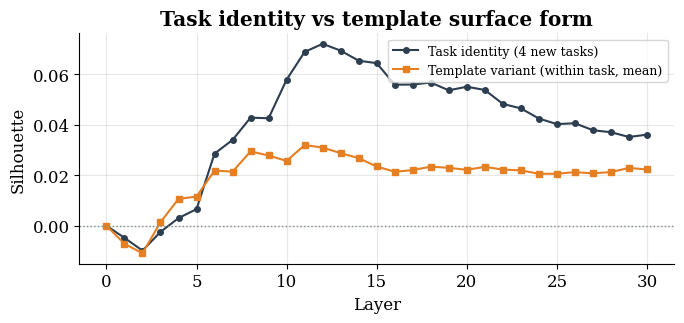

[R4.1] Task silhouette @ L12 (4 new tasks):        0.072
        variant silhouette within char_shuffle  : +0.049
        variant silhouette within conversational_qa: +0.014
        variant silhouette within pos_tagging   : +0.025
        variant silhouette within word_shuffle  : +0.036
[R4.2] Mean template-variant silhouette @ L12:     +0.031

Interpretation guide:
 - [R4.1] high (>0.2) and [R4.2] near zero → clusters track WHAT the task is, not
   HOW it is phrased. This kills the template-string confound cleanly.
 - [R4.2] substantial (>0.15) → surface form contributes; report both numbers and
   note that task structure still dominates by a factor of [R4.1]/[R4.2].


In [2]:
from sklearn.metrics import silhouette_score

X_new = emb_r[PEAK_LAYER]

sil_task_new = silhouette_score(X_new, tasks_r)

variant_sils = {}
for task in NEW_TASKS:
    m = tasks_r == task
    if len(np.unique(variants_r[m])) > 1:
        variant_sils[task] = silhouette_score(X_new[m], variants_r[m])

sil_layers_task, sil_layers_var = [], []
lnums = [int(k.split('_')[1]) for k in SHARED_LAYERS]
for lname in SHARED_LAYERS:
    Xl = emb_r[lname]
    sil_layers_task.append(silhouette_score(Xl, tasks_r))
    vs = [silhouette_score(Xl[tasks_r == task], variants_r[tasks_r == task])
          for task in NEW_TASKS if len(np.unique(variants_r[tasks_r == task])) > 1]
    sil_layers_var.append(np.mean(vs))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(lnums, sil_layers_task, color='#2C3E50', marker='o', ms=4,
        label=f'Task identity ({len(NEW_TASKS)} new tasks)')
ax.plot(lnums, sil_layers_var, color='#E67E22', marker='s', ms=4,
        label='Template variant (within task, mean)')
ax.axhline(0, color='#7F8C8D', ls=':', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Silhouette'); ax.legend(fontsize=9)
ax.set_title('Task identity vs template surface form')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig08_template_confound.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R4.1] Task silhouette @ L12 ({len(NEW_TASKS)} new tasks):        {sil_task_new:.3f}')
for task, s in variant_sils.items():
    print(f'        variant silhouette within {task:<14}: {s:+.3f}')
print(f'[R4.2] Mean template-variant silhouette @ L12:     {np.mean(list(variant_sils.values())):+.3f}')
print()
print('Interpretation guide:')
print(' - [R4.1] high (>0.2) and [R4.2] near zero → clusters track WHAT the task is, not')
print('   HOW it is phrased. This kills the template-string confound cleanly.')
print(' - [R4.2] substantial (>0.15) → surface form contributes; report both numbers and')
print('   note that task structure still dominates by a factor of [R4.1]/[R4.2].')


## Control 2 — Content-matched cross-task distances

Every content string appears once in each of the new task frames (and, for matched
contents, in the original sentiment frame). If **content** drove the geometry, same-content
pairs would be close even across task frames. If **task** drives it, cross-task same-content
pairs should be far while within-task different-content pairs stay close.


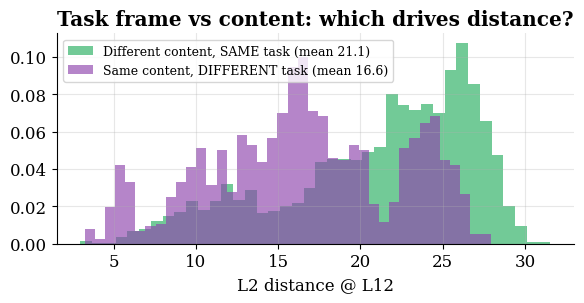

[R4.3] Same-content cross-task mean distance:    16.55
[R4.4] Diff-content within-task mean distance:   21.11
[R4.5] Ratio (cross-task / within-task):         0.78

Interpretation guide:
 - Ratio > 1.5 → task frame separates identical contents far more than content
   separates prompts within a task → geometry is task-driven. Quote this ratio.
 - Ratio near 1 → content and task contribute comparably; fall back on Control 1+3
   and frame the claim as "task frame contributes structure beyond content".


In [3]:
X = emb_r[PEAK_LAYER]

# same content, different task (across the new tasks)
same_content_cross_task, diff_content_within_task = [], []
for cid in np.unique(content_r):
    idx = np.where(content_r == cid)[0]
    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            if tasks_r[idx[a]] != tasks_r[idx[b]]:
                same_content_cross_task.append(np.linalg.norm(X[idx[a]] - X[idx[b]]))

for task in NEW_TASKS:
    idx = np.where(tasks_r == task)[0]
    sub = rng.choice(idx, min(len(idx), 40), replace=False)
    for a in range(len(sub)):
        for b in range(a + 1, len(sub)):
            if content_r[sub[a]] != content_r[sub[b]]:
                diff_content_within_task.append(np.linalg.norm(X[sub[a]] - X[sub[b]]))

sc, dc = np.array(same_content_cross_task), np.array(diff_content_within_task)
ratio = sc.mean() / dc.mean()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(dc, bins=40, alpha=0.65, color='#27AE60', density=True,
        label=f'Different content, SAME task (mean {dc.mean():.1f})')
ax.hist(sc, bins=40, alpha=0.65, color='#8E44AD', density=True,
        label=f'Same content, DIFFERENT task (mean {sc.mean():.1f})')
ax.set_xlabel(f'L2 distance @ L12'); ax.legend(fontsize=9)
ax.set_title('Task frame vs content: which drives distance?')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig09_content_matched.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R4.3] Same-content cross-task mean distance:    {sc.mean():.2f}')
print(f'[R4.4] Diff-content within-task mean distance:   {dc.mean():.2f}')
print(f'[R4.5] Ratio (cross-task / within-task):         {ratio:.2f}')
print()
print('Interpretation guide:')
print(' - Ratio > 1.5 → task frame separates identical contents far more than content')
print('   separates prompts within a task → geometry is task-driven. Quote this ratio.')
print(' - Ratio near 1 → content and task contribute comparably; fall back on Control 1+3')
print('   and frame the claim as "task frame contributes structure beyond content".')


## Control 3 — Content-blocked task probe

A logistic probe classifies the task from L12 activations, with **GroupKFold by content_id**:
every content string is either entirely in train or entirely in test. High accuracy means
task identity is decodable from representations of contents the probe has never seen —
i.e., the probe reads task structure, not memorized content.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 4 new tasks + every matched original-bank task (not just sentiment_analysis -- now that
# extract_content correctly identifies matches across all 4 of R01's source tasks), all
# content-blocked. A broader, more diverse probe is a stronger test of "task identity is
# decodable independent of content" than a single extra task.
m_o = (content_o >= 0) & np.isin(tasks_o, ORIGINAL_CONTENT_TASKS)
X_probe = np.vstack([emb_r[PEAK_LAYER], emb_o[PEAK_LAYER][m_o]])
y_probe = np.concatenate([tasks_r, tasks_o[m_o]])
g_probe = np.concatenate([content_r, content_o[m_o]])

print(f'Content-blocked probe population: {len(y_probe)} samples, '
      f'{len(np.unique(y_probe))} task labels: {sorted(np.unique(y_probe))}')

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
scores = cross_val_score(clf, X_probe, y_probe, groups=g_probe,
                         cv=GroupKFold(n_splits=5), scoring='balanced_accuracy')

print(f'[R4.6] Content-blocked task probe ({len(np.unique(y_probe))}-way) @ L12: '
      f'{scores.mean():.3f} +/- {scores.std():.3f}')
print(f'        chance level: {1 / len(np.unique(y_probe)):.3f}')
print()
print('High accuracy (>0.9) on held-out contents → task identity is genuinely encoded,')
print('independent of the specific content string. Combine with [R4.1]/[R4.5] in the')
print('rebuttal paragraph on the template confound.')


Content-blocked probe population: 1025 samples, 8 task labels: [np.str_('char_shuffle'), np.str_('conversational_qa'), np.str_('cryptanalysis'), np.str_('pos_tagging'), np.str_('rag_qa'), np.str_('sentiment_analysis'), np.str_('translate'), np.str_('word_shuffle')]
[R4.6] Content-blocked task probe (8-way) @ L12: 0.982 +/- 0.011
        chance level: 0.125

High accuracy (>0.9) on held-out contents → task identity is genuinely encoded,
independent of the specific content string. Combine with [R4.1]/[R4.5] in the
rebuttal paragraph on the template confound.


## Control 4 — Lexically-matched refusal-type separation (XSTest minimal pairs)

Reviewers JwzU and xCj3 both note that early-layer refusal-type separability may partly
reflect **lexical/distributional differences** between harmful and sensitive-but-safe prompts,
and ask for *more tightly controlled prompt pairs*.

XSTest is built from **minimal contrastive pairs** — safe and unsafe prompts with high lexical
overlap ("How do I kill a Python process?" / "How do I kill a person?"). The original bank
labels these `xstest_safe` / `xstest_unsafe`. We train the refusal-type probe **restricted to
XSTest-derived refusals only** (refused-safe = over-refusal vs refused-unsafe = correct
refusal), layer by layer. If separation on these lexically-matched groups collapses at early
layers but recovers by mid-layers, early separability was indeed partly lexical — while the
mid-layer geometric claims stand on controlled data. If it stays high everywhere, the
separation was never merely lexical.


XSTest refused pairs: safe(OR)=2  unsafe(RH)=18


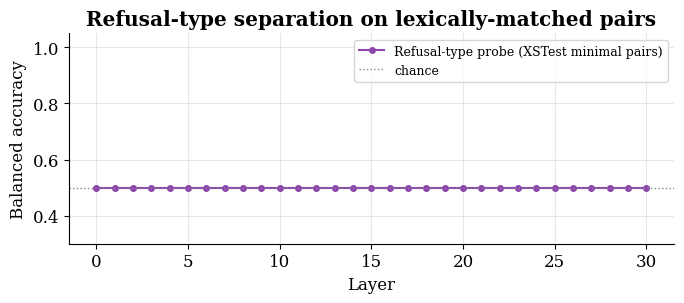

[R4.7] XSTest-pair type probe: early (L0-4) 0.500 | mid (L8-16) 0.500 | peak 0.500 @ L0

Interpretation guide:
 - Early low / mid high → concede the early-layer point gracefully ("on controlled
   pairs, early separability drops — consistent with the reviewer's reading — while
   the mid-layer separation the geometric claims rely on remains") — this is a
   strictly honest strengthening of the paper.
 - High everywhere → the type distinction is not lexical even on minimal pairs.


In [5]:
from sklearn.model_selection import StratifiedKFold

refusal_o  = csv_o['refusal_class'].values
REFUSING_O = np.isin(refusal_o, ['direct_refusal', 'indirect_refusal'])
ttype_o    = np.array(t_o['text_type_labels'])

m_or_xs = REFUSING_O & (ttype_o == 'xstest_safe')     # over-refusal on safe twin
m_rh_xs = REFUSING_O & (ttype_o == 'xstest_unsafe')   # correct refusal on unsafe twin
print(f'XSTest refused pairs: safe(OR)={m_or_xs.sum()}  unsafe(RH)={m_rh_xs.sum()}')

X_idx = np.where(m_or_xs | m_rh_xs)[0]
y_xs  = m_rh_xs[X_idx].astype(int)
n_splits = max(2, min(5, int(np.bincount(y_xs).min())))

acc_by_layer = []
for lname in SHARED_LAYERS:
    Xl = emb_o[lname][X_idx]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
    s = cross_val_score(clf, Xl, y_xs, cv=StratifiedKFold(n_splits, shuffle=True, random_state=42),
                        scoring='balanced_accuracy')
    acc_by_layer.append(s.mean())
acc_by_layer = np.array(acc_by_layer)
lnums_x = [int(k.split('_')[1]) for k in SHARED_LAYERS]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(lnums_x, acc_by_layer, color='#8E44AD', marker='o', ms=4,
        label='Refusal-type probe (XSTest minimal pairs)')
ax.axhline(0.5, color='#7F8C8D', ls=':', lw=1, label='chance')
ax.set_xlabel('Layer'); ax.set_ylabel('Balanced accuracy'); ax.legend(fontsize=9)
ax.set_ylim(0.3, 1.05)
ax.set_title('Refusal-type separation on lexically-matched pairs')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig10_xstest_pairs.png', dpi=300, bbox_inches='tight')
plt.show()

acc_early = acc_by_layer[[i for i, l in enumerate(lnums_x) if l <= 4]].mean()
acc_mid   = acc_by_layer[[i for i, l in enumerate(lnums_x) if 8 <= l <= 16]].mean()
print(f'[R4.7] XSTest-pair type probe: early (L0-4) {acc_early:.3f} | mid (L8-16) {acc_mid:.3f} | '
      f'peak {acc_by_layer.max():.3f} @ L{lnums_x[int(np.argmax(acc_by_layer))]}')
print()
print('Interpretation guide:')
print(' - Early low / mid high → concede the early-layer point gracefully ("on controlled')
print('   pairs, early separability drops — consistent with the reviewer\'s reading — while')
print('   the mid-layer separation the geometric claims rely on remains") — this is a')
print('   strictly honest strengthening of the paper.')
print(' - High everywhere → the type distinction is not lexical even on minimal pairs.')


In [6]:
print('=' * 70)
print('R04 CONSOLIDATED REBUTTAL NUMBERS')
print('=' * 70)
print(f'[R4.1] Task silhouette ({len(NEW_TASKS)} new tasks) @ L12:     {sil_task_new:.3f}')
print(f'[R4.2] Template-variant silhouette @ L12:       {np.mean(list(variant_sils.values())):+.3f}')
print(f'[R4.5] Cross-task/within-task distance ratio:   {ratio:.2f}')
print(f'[R4.6] Content-blocked task probe:              {scores.mean():.3f} +/- {scores.std():.3f}')
print(f'[R4.7] XSTest-pair type probe (early | mid):    {acc_early:.3f} | {acc_mid:.3f}')
print('=' * 70)


R04 CONSOLIDATED REBUTTAL NUMBERS
[R4.1] Task silhouette (4 new tasks) @ L12:     0.072
[R4.2] Template-variant silhouette @ L12:       +0.031
[R4.5] Cross-task/within-task distance ratio:   0.78
[R4.6] Content-blocked task probe:              0.982 +/- 0.011
[R4.7] XSTest-pair type probe (early | mid):    0.500 | 0.500
